In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [4]:
df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
df.info()
df['ocean_proximity'].unique()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


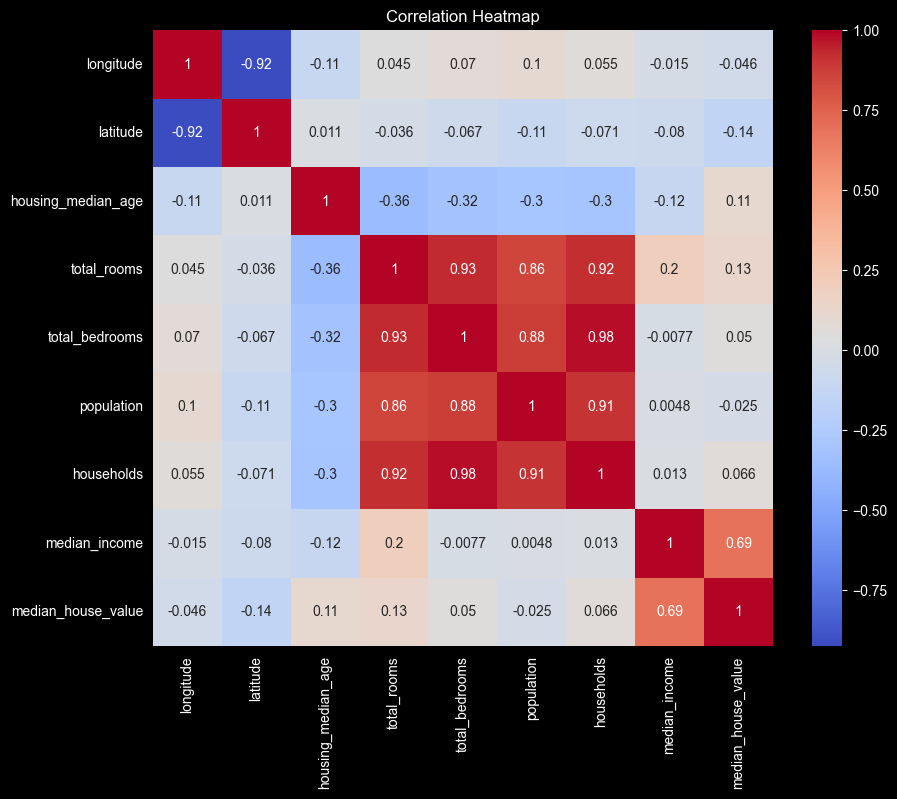

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)

plt.title("Correlation Heatmap")
plt.show()

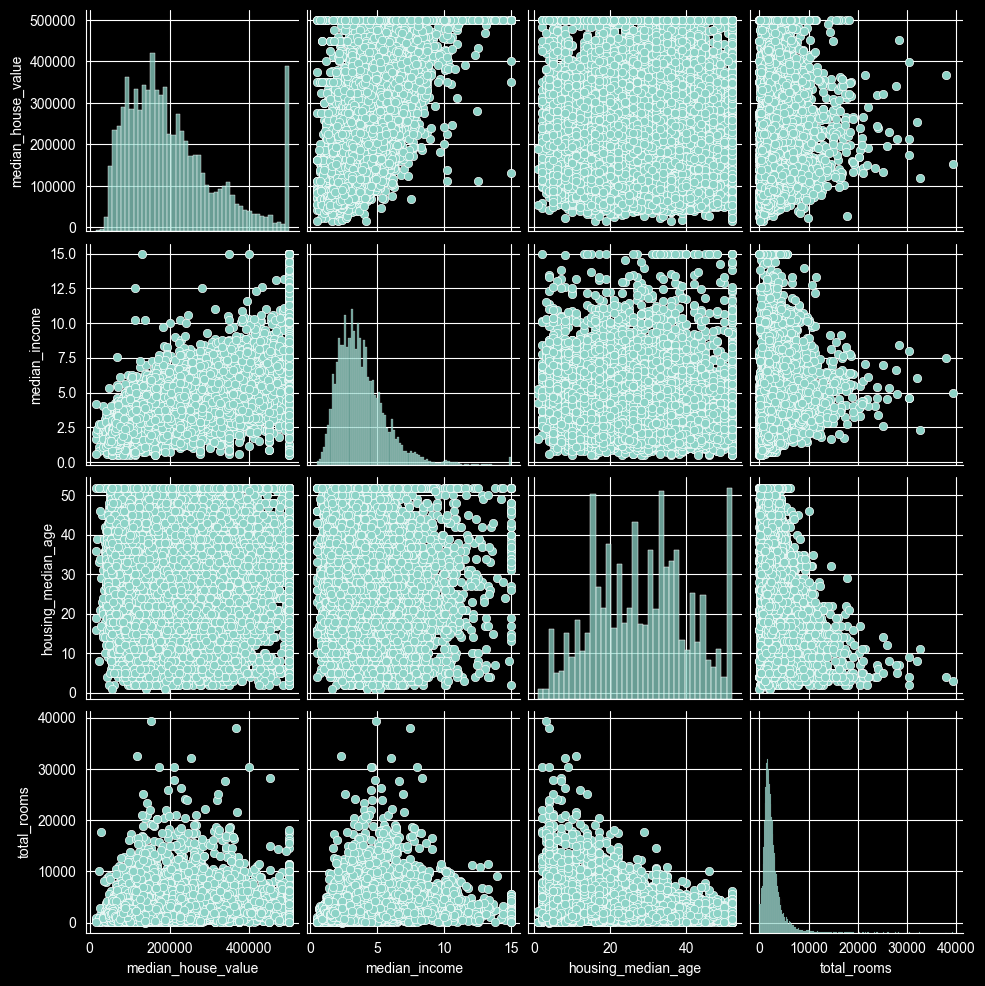

In [60]:
sns.pairplot(df[['median_house_value','median_income','housing_median_age','total_rooms']])

plt.show()

In [61]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [62]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [63]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [64]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

In [65]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [71]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [72]:
X_const = add_constant(X)
X_const = X_const.astype(float)

In [74]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print(vif_data)

                       Feature           VIF
0                        const  34200.077264
1                    longitude     18.399275
2                     latitude     20.430398
3           housing_median_age      1.323797
4                  total_rooms     16.579447
5               total_bedrooms     35.780208
6                   population      6.773558
7                   households     34.806546
8                median_income      1.995203
9          rooms_per_household      1.635879
10           bedrooms_per_room      2.193200
11    population_per_household      1.063360
12      ocean_proximity_INLAND      2.879674
13      ocean_proximity_ISLAND      1.002082
14    ocean_proximity_NEAR BAY      1.565853
15  ocean_proximity_NEAR OCEAN      1.198867


In [75]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
X_simple = df[["median_income"]]
y = df["median_house_value"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

In [78]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

In [79]:
mae_simple = mean_absolute_error(y_test_s, y_pred_simple)

rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))

r2_simple = r2_score(y_test_s, y_pred_simple)

print("Simple Linear Regression")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

Simple Linear Regression
MAE: 62990.86530093761
RMSE: 84209.01241414454
R2: 0.45885918903846656


In [80]:
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)

rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression")
print("MAE:", mae_multiple)
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)

Multiple Linear Regression
MAE: 50888.660015720314
RMSE: 72668.53837868226
R2: 0.5970176824350761


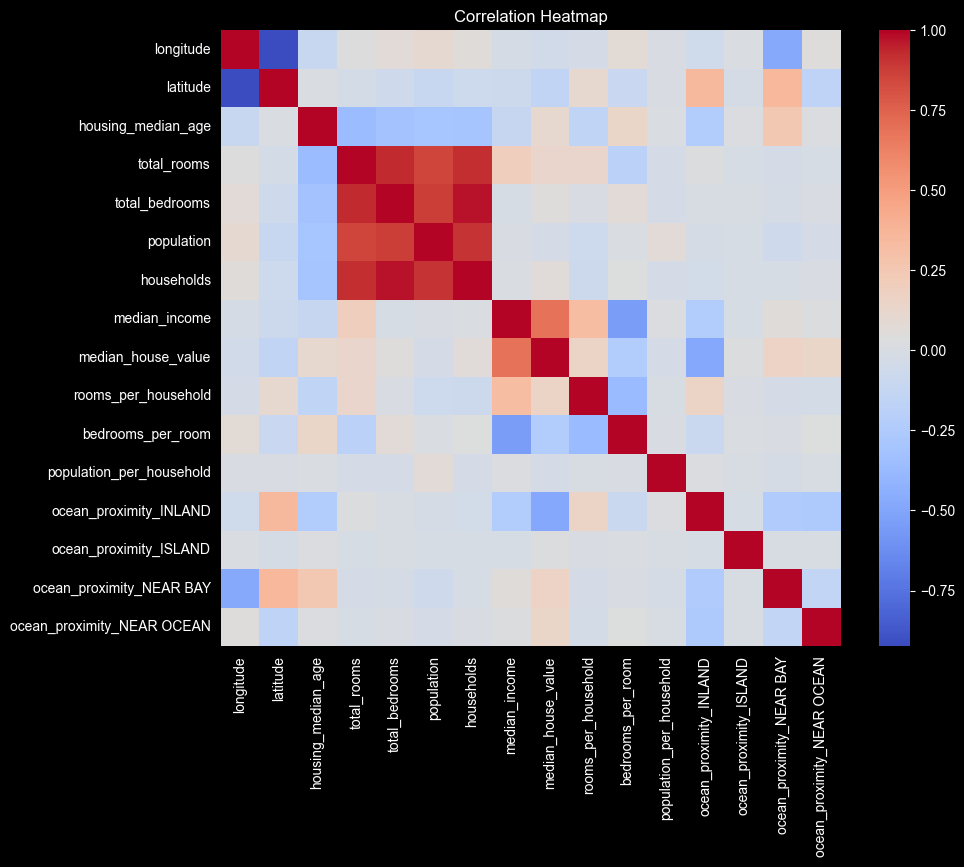

In [81]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

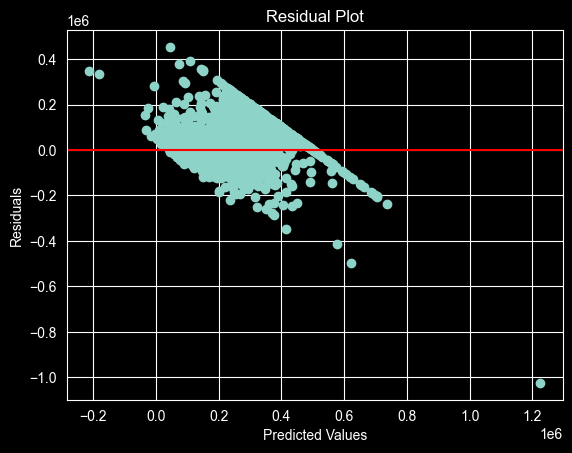

In [83]:
residuals = y_test - y_pred_multiple

plt.scatter(y_pred_multiple, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [9]:
plt.scatter(y_test, y_pred_multiple)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

NameError: name 'y_test' is not defined